### Setup

In [ ]:
# setup for colab
from google.colab import drive
drive.mount('/content/drive')

os.chdir("/content/drive/MyDrive/D68_project")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install -U transformers==4.44.2 accelerate safetensors pillow==10.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.1 MB/s eta 0:00:00


In [ ]:
import json
import os
import random

import torch
import torch.nn.functional as F
import transformers
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print(transformers.__version__)
print(PIL.__version__)


4.44.2
11.3.0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("NO GPU")

GPU: Tesla T4


### Load Model

In [ ]:
from transformers import (
  LlavaForConditionalGeneration,
  AutoTokenizer,
  AutoProcessor,
  CLIPImageProcessor
)

checkpoint = "Intel/llava-gemma-2b"

# Load model
model = LlavaForConditionalGeneration.from_pretrained(checkpoint,torch_dtype=torch.float16).to(device)
processor = AutoProcessor.from_pretrained(checkpoint)

model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

LlavaForConditionalGeneration(
  (vision_tower): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
        (position_embedding): Embedding(577, 1024)
      )
      (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-23): 24 x CLIPEncoderLayer(
            (self_attn): CLIPSdpaAttention(
              (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): Q

### Add deffusion noise

#### Import method

In [ ]:
import sys
sys.path.append("external/VCD")

from vcd_add_noise import add_diffusion_noise


#### Test add noise

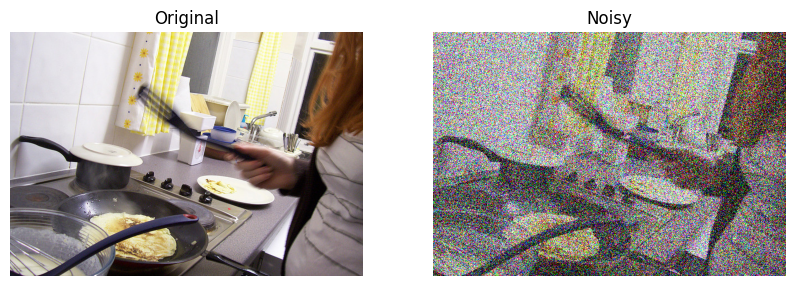

In [ ]:
img = Image.open("./data/images/COCO_val2014_000000580294.jpg").convert("RGB")
img_tensor = transforms.ToTensor()(img)

# add noise
noise_step = 500
noisy_tensor = add_diffusion_noise(img_tensor, noise_step)

noisy_img = to_pil_image(noisy_tensor.clamp(0, 1))

# display images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy_img)
plt.title("Noisy")
plt.axis("off")

plt.show()



### Generate noisy images

In [ ]:
input_dir = "./data/images"
output_dir = "./data/noisy_images"
os.makedirs(output_dir, exist_ok=True)

noise_step = 500

for i, filename in enumerate(os.listdir(input_dir)):
    if not filename.lower().endswith((".jpg")):
        continue

    torch.manual_seed(i)

    img = Image.open(os.path.join(input_dir, filename)).convert("RGB")
    img_tensor = transforms.ToTensor()(img)

    noisy_tensor = add_diffusion_noise(img_tensor, noise_step=500)
    noisy_img = to_pil_image(noisy_tensor.clamp(0, 1))

    noisy_img.save(os.path.join(output_dir, filename))


### VCD step

In [ ]:
YES_ID = processor.tokenizer.encode("Yes", add_special_tokens=False)[0]
NO_ID = processor.tokenizer.encode("No", add_special_tokens=False)[0]

def vcd_one_step_generate(
    model,
    processor,
    image,
    question,
    device,
    noisy_image,
    cd_alpha=1,
    cd_beta=0.1,
    decision_mode="argmax",   # "argmax" or "sample"
):

    prompt = processor.tokenizer.apply_chat_template(
        [{'role': 'user', 'content': f"<image>\n{question}"}],
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(device)

    inputs_cd = processor(
        text=prompt,
        images=noisy_image,
        return_tensors="pt"
    ).to(device)

    # clean forward
    with torch.no_grad():
        outputs = model(
            **inputs,
            return_dict=True,
            output_attentions=False,
            output_hidden_states=False,
        )
    next_token_logits = outputs.logits[:, -1, :]

    # noisy forward
    with torch.no_grad():
        outputs_cd = model(
            **inputs_cd,
            return_dict=True,
            output_attentions=False,
            output_hidden_states=False,
        )
    next_token_logits_cd = outputs_cd.logits[:, -1, :]

    # VCD formula
    cutoff = torch.log(torch.tensor(cd_beta, device=device)) + next_token_logits.max(dim=-1, keepdim=True).values

    diffs = (1 + cd_alpha) * next_token_logits - cd_alpha * next_token_logits_cd
    cd_logits = diffs.masked_fill(next_token_logits < cutoff, -float("inf"))

    # full-vocab probabilities for reporting
    clean_probs = torch.softmax(next_token_logits, dim=-1)
    noisy_probs = torch.softmax(next_token_logits_cd, dim=-1)
    vcd_probs = torch.softmax(cd_logits, dim=-1)

    # prediction only between Yes / No
    clean_yn_logits = next_token_logits[0, [YES_ID, NO_ID]]
    vcd_yn_logits = cd_logits[0, [YES_ID, NO_ID]]

    if decision_mode == "sample":
        clean_idx = torch.multinomial(torch.softmax(clean_yn_logits, dim=0), 1).item()
        vcd_idx = torch.multinomial(torch.softmax(vcd_yn_logits, dim=0), 1).item()
    elif decision_mode == "argmax":
        clean_idx = torch.argmax(clean_yn_logits).item()
        vcd_idx = torch.argmax(vcd_yn_logits).item()
    else:
        raise ValueError("decision_mode must be 'argmax' or 'sample'")

    clean_pred = "yes" if clean_idx == 0 else "no"
    vcd_pred = "yes" if vcd_idx == 0 else "no"

    return {
        "clean_pred": clean_pred,
        "vcd_pred": vcd_pred,
        "clean_yes_prob": clean_probs[0, YES_ID].item(),
        "clean_no_prob": clean_probs[0, NO_ID].item(),
        "noisy_yes_prob": noisy_probs[0, YES_ID].item(),
        "noisy_no_prob": noisy_probs[0, NO_ID].item(),
        "vcd_yes_prob": vcd_probs[0, YES_ID].item(),
        "vcd_no_prob": vcd_probs[0, NO_ID].item(),
    }

### Run VCD on the dataset

#### Random

In [ ]:
random.seed(302)
torch.manual_seed(302)

data = []
with open("./external/POPE/coco_pope_random.json", "r") as f:
    for line in f:
        data.append(json.loads(line))

# take a subset of n images (6*n questions)
# ids = random.sample(range(500), 100)
# subset = [item for i in ids for item in data[6*i : 6*i+6]]

image_folder = "./data/images"
noisy_image_folder = "./data/noisy_images"

results_random = []
# for item in subset:
for item in data:

    image_name = item["image"]
    question = item["text"]

    image = Image.open(f"{image_folder}/{image_name}").convert("RGB")
    noisy_image = Image.open(f"{noisy_image_folder}/{image_name}").convert("RGB")

    result = vcd_one_step_generate(
        model=model,
        processor=processor,
        image=image,
        question=question,
        device=device,
        noisy_image=noisy_image,
        cd_alpha=1,
        decision_mode="sample",
    )

    result["question_id"] = item["question_id"]
    result["image"] = image_name
    result["question"] = question
    result["gt"] = item["label"]
    result["vcd_correct"] = (result["vcd_pred"] == item["label"])
    result["orig_correct"] = (result["clean_pred"] == item["label"])

    results_random.append(result)


In [ ]:
with open("results_random.json", "w") as f:
    json.dump(results_random, f, indent=2)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_true = [r["gt"] for r in results_random]
y_vcd = [r["vcd_pred"] for r in results_random]
y_orig = [r["clean_pred"] for r in results_random]

vcd_acc = accuracy_score(y_true, y_vcd)
orig_acc = accuracy_score(y_true, y_orig)

y_true_bin = [1 if y == "yes" else 0 for y in y_true]
y_vcd_bin = [1 if y == "yes" else 0 for y in y_vcd]
y_orig_bin = [1 if y == "yes" else 0 for y in y_orig]

vcd_f1 = f1_score(y_true_bin, y_vcd_bin)
orig_f1 = f1_score(y_true_bin, y_orig_bin)
vcd_precision = precision_score(y_true_bin, y_vcd_bin)
vcd_recall = recall_score(y_true_bin, y_vcd_bin)

orig_precision = precision_score(y_true_bin, y_orig_bin)
orig_recall = recall_score(y_true_bin, y_orig_bin)

print()
print(f"VCD      Accuracy: {vcd_acc:.4f} | F1: {vcd_f1:.4f} | P: {vcd_precision:.4f} | R: {vcd_recall:.4f}")
print(f"Original Accuracy: {orig_acc:.4f} | F1: {orig_f1:.4f} | P: {orig_precision:.4f} | R: {orig_recall:.4f}")



VCD      Accuracy: 0.7773 | F1: 0.8065 | P: 0.7131 | R: 0.9280
Original Accuracy: 0.7697 | F1: 0.8018 | P: 0.7036 | R: 0.9320


#### Popular

In [ ]:
random.seed(325)
torch.manual_seed(325)

data = []
with open("./external/POPE/coco_pope_popular.json", "r") as f:
    for line in f:
        data.append(json.loads(line))

# take a subset of n images (6*n questions)
# ids = random.sample(range(500), 10)
# subset = [item for i in ids for item in data[6*i : 6*i+6]]

image_folder = "./data/images"
noisy_image_folder = "./data/noisy_images"

results_popular = []
# for item in subset:
for item in data:

    image_name = item["image"]
    question = item["text"]

    image = Image.open(f"{image_folder}/{image_name}").convert("RGB")
    noisy_image = Image.open(f"{noisy_image_folder}/{image_name}").convert("RGB")

    result = vcd_one_step_generate(
        model=model,
        processor=processor,
        image=image,
        question=question,
        device=device,
        noisy_image=noisy_image,
        cd_alpha=1,
        decision_mode="sample",
    )

    result["question_id"] = item["question_id"]
    result["image"] = image_name
    result["question"] = question
    result["gt"] = item["label"]
    result["vcd_correct"] = (result["vcd_pred"] == item["label"])
    result["orig_correct"] = (result["clean_pred"] == item["label"])

    results_popular.append(result)


In [ ]:
with open("results_popular.json", "w") as f:
    json.dump(results_popular, f, indent=2)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_true = [r["gt"] for r in results_popular]
y_vcd = [r["vcd_pred"] for r in results_popular]
y_orig = [r["clean_pred"] for r in results_popular]

vcd_acc = accuracy_score(y_true, y_vcd)
orig_acc = accuracy_score(y_true, y_orig)

y_true_bin = [1 if y == "yes" else 0 for y in y_true]
y_vcd_bin = [1 if y == "yes" else 0 for y in y_vcd]
y_orig_bin = [1 if y == "yes" else 0 for y in y_orig]

vcd_f1 = f1_score(y_true_bin, y_vcd_bin)
orig_f1 = f1_score(y_true_bin, y_orig_bin)
vcd_precision = precision_score(y_true_bin, y_vcd_bin)
vcd_recall = recall_score(y_true_bin, y_vcd_bin)

orig_precision = precision_score(y_true_bin, y_orig_bin)
orig_recall = recall_score(y_true_bin, y_orig_bin)

print()
print(f"VCD      Accuracy: {vcd_acc:.4f} | F1: {vcd_f1:.4f} | P: {vcd_precision:.4f} | R: {vcd_recall:.4f}")
print(f"Original Accuracy: {orig_acc:.4f} | F1: {orig_f1:.4f} | P: {orig_precision:.4f} | R: {orig_recall:.4f}")



VCD      Accuracy: 0.7333 | F1: 0.7762 | P: 0.6688 | R: 0.9247
Original Accuracy: 0.7257 | F1: 0.7707 | P: 0.6620 | R: 0.9220


#### Adversarial

In [ ]:
random.seed(799)
torch.manual_seed(799)

data = []
with open("./external/POPE/coco_pope_adversarial.json", "r") as f:
    for line in f:
        data.append(json.loads(line))

# take a subset of n images (6*n questions)
# ids = random.sample(range(500), 100)
# subset = [item for i in ids for item in data[6*i : 6*i+6]]

image_folder = "./data/images"
noisy_image_folder = "./data/noisy_images"

results_adversarial = []
# for item in subset:
for item in data:

    image_name = item["image"]
    question = item["text"]

    image = Image.open(f"{image_folder}/{image_name}").convert("RGB")
    noisy_image = Image.open(f"{noisy_image_folder}/{image_name}").convert("RGB")

    result = vcd_one_step_generate(
        model=model,
        processor=processor,
        image=image,
        question=question,
        device=device,
        noisy_image=noisy_image,
        cd_alpha=1,
        decision_mode="sample",
    )

    result["question_id"] = item["question_id"]
    result["image"] = image_name
    result["question"] = question
    result["gt"] = item["label"]
    result["vcd_correct"] = (result["vcd_pred"] == item["label"])
    result["orig_correct"] = (result["clean_pred"] == item["label"])

    results_adversarial.append(result)



In [ ]:
with open("results_adversarial.json", "w") as f:
    json.dump(results_adversarial, f, indent=2)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_true = [r["gt"] for r in results_adversarial]
y_vcd = [r["vcd_pred"] for r in results_adversarial]
y_orig = [r["clean_pred"] for r in results_adversarial]

vcd_acc = accuracy_score(y_true, y_vcd)
orig_acc = accuracy_score(y_true, y_orig)

y_true_bin = [1 if y == "yes" else 0 for y in y_true]
y_vcd_bin = [1 if y == "yes" else 0 for y in y_vcd]
y_orig_bin = [1 if y == "yes" else 0 for y in y_orig]

vcd_f1 = f1_score(y_true_bin, y_vcd_bin)
orig_f1 = f1_score(y_true_bin, y_orig_bin)
vcd_precision = precision_score(y_true_bin, y_vcd_bin)
vcd_recall = recall_score(y_true_bin, y_vcd_bin)

orig_precision = precision_score(y_true_bin, y_orig_bin)
orig_recall = recall_score(y_true_bin, y_orig_bin)

print()
print(f"VCD      Accuracy: {vcd_acc:.4f} | F1: {vcd_f1:.4f} | P: {vcd_precision:.4f} | R: {vcd_recall:.4f}")
print(f"Original Accuracy: {orig_acc:.4f} | F1: {orig_f1:.4f} | P: {orig_precision:.4f} | R: {orig_recall:.4f}")



VCD      Accuracy: 0.7077 | F1: 0.7607 | P: 0.6439 | R: 0.9293
Original Accuracy: 0.6883 | F1: 0.7476 | P: 0.6281 | R: 0.9233
